# Evolving a Lunar Lander with differentiable Genetic Programming

## Installation
To install the required libraries run the command:

In [28]:
!pip install -r requirements.txt

  Using cached box2d-py-2.3.5.tar.gz (374 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
INFO: pip is looking at multiple versions of gymnasium[box2d] to determine which version is compatible with other requirements. This could take a while.
  Using cached gymnasium-1.1.0-py3-none-any.whl.metadata (9.4 kB)
  Using cached gymnasium-1.0.0-py3-none-any.whl.metadata (9.5 kB)
  Using cached gymnasium-0.29.1-py3-none-any.whl.metadata (10 kB)
  Using cached gymnasium-0.29.0-py3-none-any.whl.metadata (10 kB)
  Using cached gymnasium-0.28.1-py3-none-any.whl.metadata (9.2 kB)
  Using cached jax_jumpy-1.0.0-py3-none-any.whl.metadata (15 kB)
  Using cached gymnasium-0.28.0-py3-none-any.whl.metadata (9.2 kB)
  Using cached gymnasium-0.27.1-py3-none-any.whl.metadata (8.5 kB)
  Using cached gymnasium_notices-0.0.1-py3-none-any.whl.metadata (1.1 kB)
INFO: pip is still looking at multiple versions of gymnasium[box2d] to determine which version 

  DEPRECATION: Building 'box2d-py' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'box2d-py'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> [41 lines of output]
      Using setuptools (version 78.1.1).
      C:\Users\samko\Desktop\Projects\TU_Delft\EA\genepromulti\.conda\lib\site-packages\setuptools\_distutils\dist.py:289: UserWarning: Unknown distribution option: 'test_suite'
        warnings.warn(msg)
      C:\Users\samko\Desktop\Projects\TU_Delft\EA\genepromulti\.conda\lib\site-packages\setuptools\dist.py:759: SetuptoolsDeprecationWarning: License c

## Imports
Imports from the standard genepro-multi library are done here. Any adjustments (e.g. different operators) should be made in the notebook. For example:

```
class SmoothOperator(Node):
  def __init__(self):
    super(SmoothOperator,self).__init__()
    self.arity = 1
    self.symb = "SmoothOperator"

  def _get_args_repr(self, args):
    return self._get_typical_repr(args,'before')

  def get_output(self, X):
    c_outs = self._get_child_outputs(X)
    return np.smoothOperation(c_outs[0])

  def get_output_pt(self, X):
    c_outs = self._get_child_outputs_pt(X)
    return torch.smoothOperation(c_outs[0])
```

In [29]:
import gymnasium as gym

from genepro.node_impl import *
from genepro.custom_node_impl import *
from genepro.evo import Evolution
from genepro.node_impl import Constant

import torch
import torch.optim as optim

import random
import os
os.chdir("C:\\Users\\filip\\Desktop\\TUDelft\\genepromulti")
import copy
from collections import namedtuple, deque

import matplotlib.pyplot as plt
from matplotlib import animation

## Reinforcement Learning Setup
Here we first setup the Gymnasium environment. Please see https://gymnasium.farama.org/environments/box2d/lunar_lander/ for more information on the environment. 

Then a memory buffer is made. This is a buffer in which state transitions are stored. When the buffer reaches its maximum capacity old transitions are replaced by new ones.

A frame buffer is initialised used to later store animation frames of the environment.

In [30]:
env = gym.make("LunarLander-v3", render_mode="rgb_array")

Box([-1.5       -1.5       -5.        -5.        -3.1415927 -5.
 -0.        -0.       ], [1.5       1.5       5.        5.        3.1415927 5.        1.
 1.       ], (8,), float32)


In [31]:
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))

class ReplayMemory(object):
    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

    def __iadd__(self, other):
      self.memory += other.memory
      return self 

    def __add__(self, other):
      self.memory = self.memory + other.memory 
      return self

In [32]:
frames = []

## Fitness Function

Here you get to be creative. The default setup evaluates 5 episodes of 300 frames. Think of what action to pick and what fitness function to use. The Multi-tree takes an input of $n \times d$ where $n$ is a batch of size 1.

In [33]:
def fitness_function_pt(multitree, num_episodes=5, episode_duration=300, render=False, ignore_done=False):
  memory = ReplayMemory(10000)
  rewards = []

  for _ in range(num_episodes):
    # get initial state of the environment
    observation = env.reset()
    observation = observation[0]
    for _ in range(episode_duration):
      if render:
        frames.append(env.render())

      input_sample = torch.from_numpy(observation.reshape((1,-1))).float()
      
      # what goes here? TODO
      action = torch.argmax(multitree.get_output_pt(input_sample))
      observation, reward, terminated, truncated, info = env.step(action.item())
      rewards.append(reward)
      output_sample = torch.from_numpy(observation.reshape((1,-1))).float()
      memory.push(input_sample, torch.tensor([[action.item()]]), output_sample, torch.tensor([reward]))
      if (terminated or truncated) and not ignore_done:
        break

  fitness = np.sum(rewards)
  return fitness, memory

def fitness_function_pt_new(multitree, num_episodes=5, episode_duration=300, render=False, ignore_done=False):
  memory = ReplayMemory(10000)
  rewards = []
  total_reward = 0
  shaped_reward = 0
  successful_landings = 0

  for ep in range(num_episodes):
      ep_reward = 0
      ep_shaped = 0
      ep_steps = 0
      landed = False

      observation = env.reset()[0]
      for t in range(episode_duration):
          if render:
              frames.append(env.render())
          input_sample = torch.from_numpy(observation.reshape((1,-1))).float()
          action_tensor = multitree.get_output_pt(input_sample)
          action_probs = torch.softmax(action_tensor, dim=1)
          print(action_probs)

          action = torch.multinomial(action_probs, num_samples=1).item()
        #   print(f"Action: {action}")          
          observation, reward, terminated, truncated, info = env.step(action)
          done = terminated or truncated
          total_reward += reward
          ep_reward += reward
          ep_steps += 1

          # Heuristic shaping
          pos_x, pos_y, vel_x, vel_y, angle, ang_vel, leg1_contact, leg2_contact = observation

          # Encourage staying near the center (x=0), and low lateral/vertical velocity
          position_penalty = -10.0 * abs(pos_x)
          velocity_penalty = -5.0 * (abs(vel_x) + abs(vel_y))

          # Penalize rotation and spinning
          rotation_penalty = -20.0 * abs(angle) - 10.0 * abs(ang_vel)

          # Bonus for making contact with both legs
          leg_contact_bonus = 10.0 * (leg1_contact + leg2_contact)

          # Bonus for hovering gently close to the ground without crashing
          hover_bonus = 0
          if pos_y < 0.25 and abs(vel_y) < 0.5 and not (leg1_contact or leg2_contact):
              hover_bonus = 10.0  # gentle hover

          # Strong bonus for soft landing
          landing_bonus = 0
          if done and reward == 100:
              landing_bonus = 100.0

          # Crash penalty
          crash_penalty = -100.0 if done and reward == -100 else 0

          # Total shaped reward
          shaped = (
              position_penalty +
              velocity_penalty +
              rotation_penalty +
              leg_contact_bonus +
              hover_bonus +
              landing_bonus +
              crash_penalty
          )
          ep_shaped += shaped

      shaped_reward += ep_shaped
      if landed:
          successful_landings += 1
    
  fitness = (
    0.3 * total_reward +
    0.5 * shaped_reward / num_episodes +
    50.0 * successful_landings  
  )
  return fitness, memory

## Evolution Setup
Here the leaf and internal nodes are defined. Think about the odds of sampling a constant in this default configurations. Also think about any operators that could be useful and add them here. 

Adjust the population size (multiple of 8 if you want to use the standard tournament selection), max generations and max tree size to taste. Be aware that each of these settings can increase the runtime.

In [34]:
from genepro.custom_node_impl import *
num_features = env.observation_space.shape[0]
print("Number of features:", num_features)
leaf_nodes = [Feature(i) for i in range(num_features)]
leaf_nodes = leaf_nodes + [Constant()] # Think about the probability of sampling a coefficient
internal_nodes = [Plus(),Minus(),Times(),Div(),IfNode(),GreaterThan(),LessThan()] #Add your own operators here

evo = Evolution(
  fitness_function_pt, internal_nodes, leaf_nodes,
  4,
  pop_size=48,
  max_gens=10,
  max_tree_size=31,
  n_jobs=8,
  verbose=True)

Number of features: 8


In [8]:
from genepro.variation import generate_random_tree
trees = [generate_random_tree(
    internal_nodes,
    leaf_nodes=leaf_nodes,
    max_depth=6,
    curr_depth=0
) for _ in range(5)]
for t in trees:
    print(t.get_readable_repr())
    print()

N type:  <class 'genepro.node_impl.Feature'>
N type:  <class 'genepro.node_impl.Constant'>
N type:  <class 'genepro.node_impl.Minus'>
N type:  <class 'genepro.node_impl.Feature'>
N type:  <class 'genepro.custom_node_impl.Abs'>
N type:  <class 'genepro.node_impl.Minus'>
N type:  <class 'genepro.custom_node_impl.Abs'>
N type:  <class 'genepro.node_impl.Constant'>
N type:  <class 'genepro.custom_node_impl.BooleanIf'>
N type:  <class 'genepro.node_impl.Constant'>
N type:  <class 'genepro.node_impl.Feature'>
N type:  <class 'genepro.custom_node_impl.BooleanIf'>
N type:  <class 'genepro.custom_node_impl.Abs'>
N type:  <class 'genepro.node_impl.Constant'>
N type:  <class 'genepro.node_impl.Plus'>
N type:  <class 'genepro.node_impl.Constant'>
N type:  <class 'genepro.custom_node_impl.Abs'>
N type:  <class 'genepro.node_impl.Plus'>
N type:  <class 'genepro.node_impl.Minus'>
N type:  <class 'genepro.custom_node_impl.Abs'>
N type:  <class 'genepro.node_impl.Constant'>
N type:  <class 'genepro.cus

## Evolve
Running this cell will use all the settings above as parameters

In [35]:
evo.evolve()

gen: 1,	best of gen fitness: -394.118,	best of gen size: 30
gen: 2,	best of gen fitness: -321.054,	best of gen size: 33
gen: 3,	best of gen fitness: -280.758,	best of gen size: 33
gen: 4,	best of gen fitness: -350.867,	best of gen size: 33
gen: 5,	best of gen fitness: -199.934,	best of gen size: 27
gen: 6,	best of gen fitness: -220.668,	best of gen size: 27
gen: 7,	best of gen fitness: -236.222,	best of gen size: 27
gen: 8,	best of gen fitness: -206.249,	best of gen size: 27
gen: 9,	best of gen fitness: -115.999,	best of gen size: 31
gen: 10,	best of gen fitness: -201.109,	best of gen size: 31


# Test

In [36]:
def get_test_score(tree):
    rewards = []

    for i in range(10):
      # get initial state
      observation = env.reset(seed=i)
      observation = observation[0]

      for _ in range(500):    
        # build up the input sample for GP
        input_sample = torch.from_numpy(observation.reshape((1,-1))).float()
        # get output (squeezing because it is encapsulated in an array)
        output = tree.get_output_pt(input_sample)
        action = torch.argmax(output)# What goes here?
        observation, reward, terminated, truncated, info = env.step(action.item())
        rewards.append(reward)

        # print(output.shape)
        # print("observation:", observation)
        # print(f"Action: {action.item()}, Reward: {reward}, terminated: {terminated}, truncated: {truncated}, info: {info}")
        # build up the output sample for GP
        output_sample = torch.from_numpy(observation.reshape((1,-1))).float()
        if (terminated or truncated):
            break

    fitness = np.sum(rewards)
    
    return fitness

best = evo.best_of_gens[-1]

print(best.get_readable_repr())
print(get_test_score(best))

['x_5', '(((x_3>if(x_1, x_0, x_6))/((x_7-x_4)<(x_4/1.695120096206665)))*(if(x_0, x_2, (x_2*x_1))/(x_4+(x_7/x_1))))', '(x_5+((x_1*(x_0-1.4035500288009644))-((x_5*x_5)-if(-3.709735870361328, 0.633075475692749, x_5))))', '(((x_7-x_4)/((((x_7-x_4)+x_5)*(x_2*(-0.5583577311991742+x_7)))-(x_5<x_1)))*(((x_5*x_2)/(x_7+x_7))>(x_7-x_4)))']
-1178.1119468035508


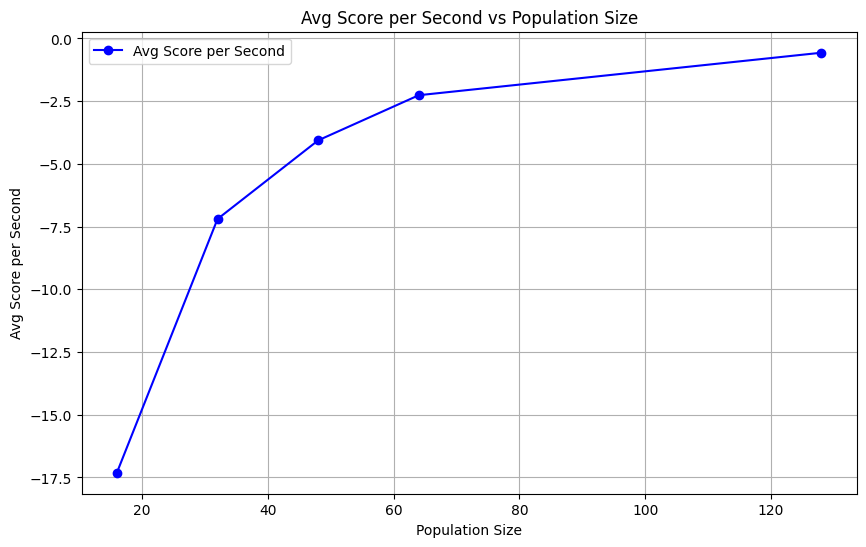

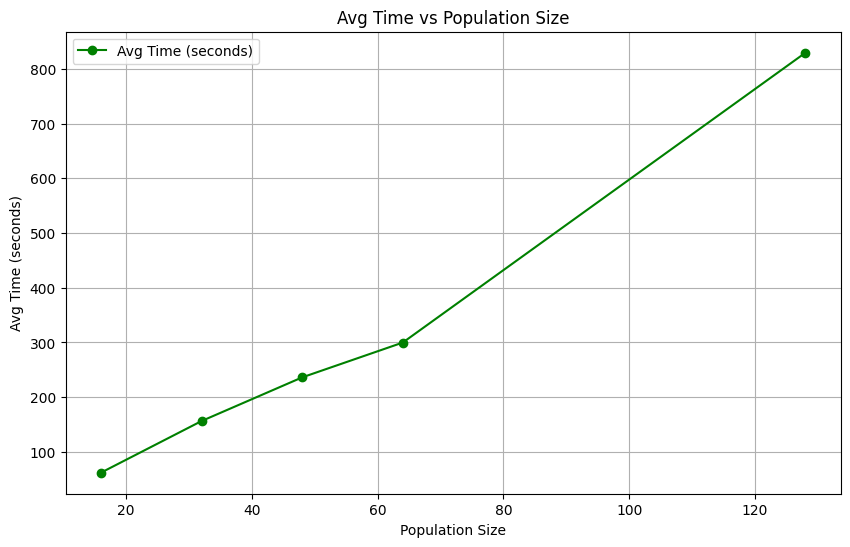

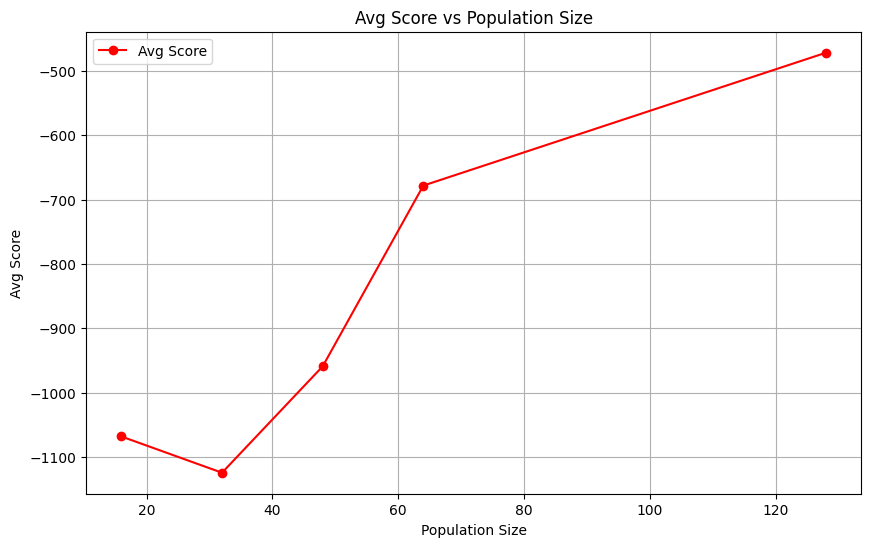

In [38]:
from datetime import datetime
import csv

def test_population_size(sizes):
    data = []
    for size in sizes:
        total_time = 0
        total_score = 0
        for i in range(5):
            start = datetime.now()
            evo = Evolution(
                fitness_function_pt, internal_nodes, leaf_nodes,
                4,
                pop_size=size,
                max_gens=10,
                max_tree_size=31,
                n_jobs=8,
                verbose=True)
            evo.evolve()
            end = datetime.now()
            time = (end-start).total_seconds()
            best = evo.best_of_gens[-1]
            test_score = get_test_score(best)
            total_time += time
            total_score += test_score

        avg_time = total_time / 5
        avg_score = total_score / 5
        avg_score_per_second = avg_score / avg_time
        print(f"size {size}, avg_time {avg_time}, avg_score {avg_score}, avg_score_per_second {avg_score_per_second}")
        data.append([size, avg_time, avg_score, avg_score_per_second])

    try:
        with open("population_sizes2.csv", mode='w', newline='') as file:
            writer = csv.writer(file)
            writer.writerow(["Population Size", "Avg Time (seconds)", "Avg Test Score", "Avg Score per Second"])
            writer.writerows(data)
        print("CSV file written successfully.")
    except Exception as e:
        print("Error while writing CSV file:", e)
    return data

def plot(data):
    sizes = [entry[0] for entry in data]
    avg_times = [entry[1] for entry in data]
    avg_scores = [entry[2] for entry in data]
    avg_scores_per_second = [entry[3] for entry in data]

    # Plot Avg Score per Second vs Population Size
    plt.figure(figsize=(10, 6))
    plt.plot(sizes, avg_scores_per_second, marker='o', label='Avg Score per Second', color='blue')
    plt.title('Avg Score per Second vs Population Size')
    plt.xlabel('Population Size')
    plt.ylabel('Avg Score per Second')
    plt.grid(True)
    plt.legend()
    plt.savefig("avg_score_per_second_vs_population_size.png")
    plt.show()

    # Plot Avg Time vs Population Size
    plt.figure(figsize=(10, 6))
    plt.plot(sizes, avg_times, marker='o', label='Avg Time (seconds)', color='green')
    plt.title('Avg Time vs Population Size')
    plt.xlabel('Population Size')
    plt.ylabel('Avg Time (seconds)')
    plt.grid(True)
    plt.legend()
    plt.savefig("avg_time_vs_population_size.png")
    plt.show()

    # Plot Avg Score vs Population Size
    plt.figure(figsize=(10, 6))
    plt.plot(sizes, avg_scores, marker='o', label='Avg Score', color='red')
    plt.title('Avg Score vs Population Size')
    plt.xlabel('Population Size')
    plt.ylabel('Avg Score')
    plt.grid(True)
    plt.legend()
    plt.savefig("avg_score_vs_population_size.png")
    plt.show()

def load_csv(filename):
    data = []
    with open(filename, mode='r', newline='') as file:
        reader = csv.reader(file)
        next(reader)
        for row in reader:
            data.append([int(row[0]), float(row[1]), float(row[2]), float(row[3])])
    return data
    

sizes = [16,32,48,64,128]
# data = test_population_size(sizes)
data = load_csv("results_baseline/population_sizes.csv")
plot(data)

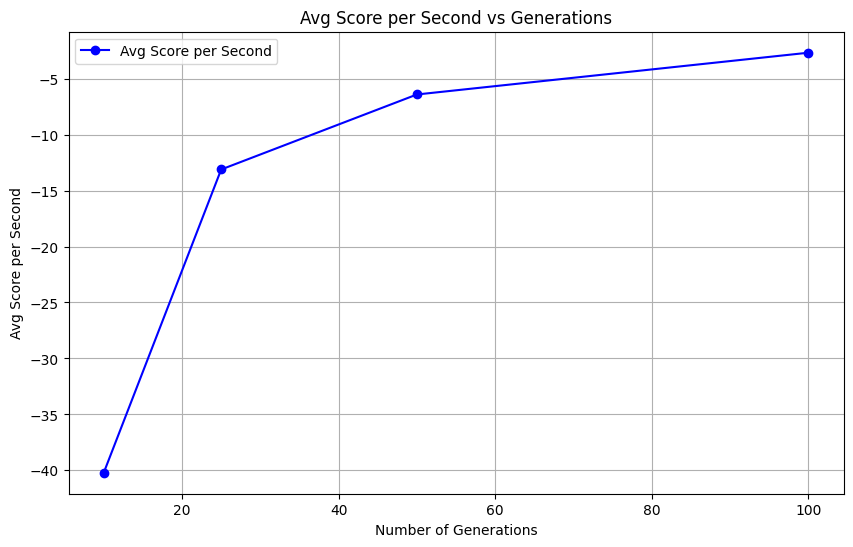

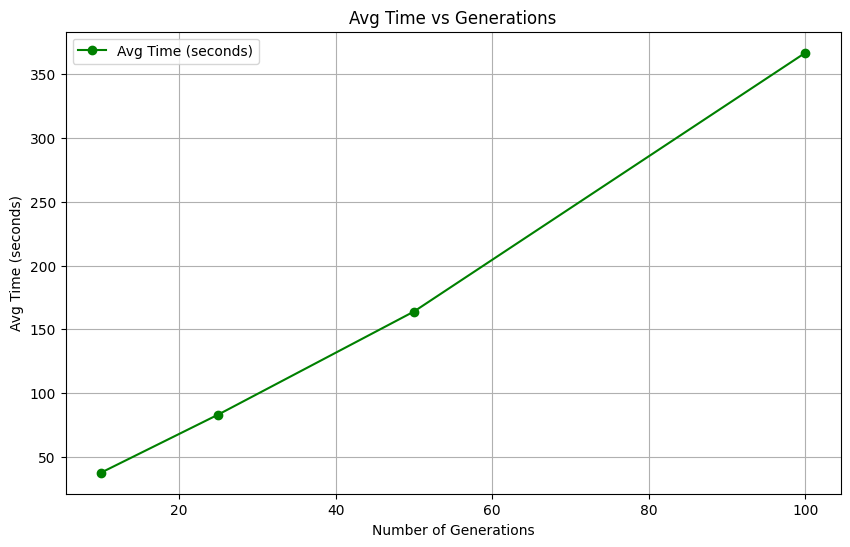

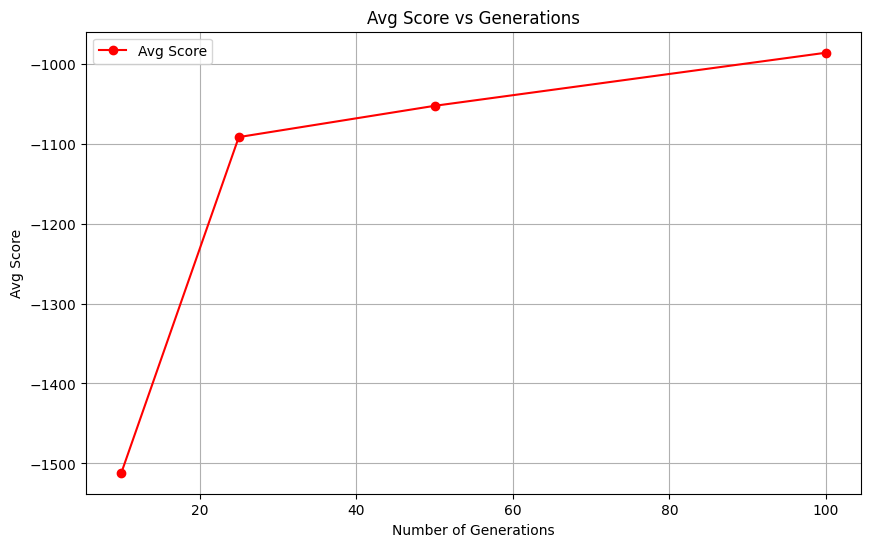

In [40]:
# Test different number of generations
from datetime import datetime
import csv
import matplotlib.pyplot as plt

def test_generation_counts(gen_counts):
    data = []
    pop_size = 16
    for gen_count in gen_counts:
        total_time = 0
        total_score = 0
        for i in range(5):
            start = datetime.now()
            evo = Evolution(
                fitness_function_pt, internal_nodes, leaf_nodes,
                4,
                pop_size=pop_size,
                max_gens=gen_count,
                max_tree_size=31,
                n_jobs=8,
                verbose=True)
            evo.evolve()
            end = datetime.now()
            time = (end - start).total_seconds()
            best = evo.best_of_gens[-1]
            test_score = get_test_score(best)
            total_time += time
            total_score += test_score

        avg_time = total_time / 5
        avg_score = total_score / 5
        avg_score_per_second = avg_score / avg_time
        print(f"Generations {gen_count}, avg_time {avg_time}, avg_score {avg_score}, avg_score_per_second {avg_score_per_second}")
        data.append([gen_count, avg_time, avg_score, avg_score_per_second])

    try:
        with open("generation_counts.csv", mode='w', newline='') as file:
            writer = csv.writer(file)
            writer.writerow(["Generations", "Avg Time (seconds)", "Avg Test Score", "Avg Score per Second"])
            writer.writerows(data)
    except Exception as e:
        print("Error while writing file:", e)
    return data

def plot(data):
    generations = [entry[0] for entry in data]
    avg_times = [entry[1] for entry in data]
    avg_scores = [entry[2] for entry in data]
    avg_scores_per_second = [entry[3] for entry in data]

    # Plot Avg Score per Second vs Generations
    plt.figure(figsize=(10, 6))
    plt.plot(generations, avg_scores_per_second, marker='o', label='Avg Score per Second', color='blue')
    plt.title('Avg Score per Second vs Generations')
    plt.xlabel('Number of Generations')
    plt.ylabel('Avg Score per Second')
    plt.grid(True)
    plt.legend()
    plt.savefig("avg_score_per_second_vs_generations.png")
    plt.show()

    # Plot Avg Time vs Generations
    plt.figure(figsize=(10, 6))
    plt.plot(generations, avg_times, marker='o', label='Avg Time (seconds)', color='green')
    plt.title('Avg Time vs Generations')
    plt.xlabel('Number of Generations')
    plt.ylabel('Avg Time (seconds)')
    plt.grid(True)
    plt.legend()
    plt.savefig("avg_time_vs_generations.png")
    plt.show()

    # Plot Avg Score vs Generations
    plt.figure(figsize=(10, 6))
    plt.plot(generations, avg_scores, marker='o', label='Avg Score', color='red')
    plt.title('Avg Score vs Generations')
    plt.xlabel('Number of Generations')
    plt.ylabel('Avg Score')
    plt.grid(True)
    plt.legend()
    plt.savefig("avg_score_vs_generations.png")
    plt.show()

def load_csv(filename):
    data = []
    with open(filename, mode='r', newline='') as file:
        reader = csv.reader(file)
        next(reader)
        for row in reader:
            data.append([int(row[0]), float(row[1]), float(row[2]), float(row[3])])
    return data

gen_counts = [10, 25, 50]
# data = test_generation_counts(gen_counts)
data = load_csv("results_baseline/generation_counts.csv")
plot(data)


gen: 1,	best of gen fitness: -564.085,	best of gen size: 26
gen: 2,	best of gen fitness: -465.031,	best of gen size: 26
gen: 3,	best of gen fitness: -576.803,	best of gen size: 26
gen: 4,	best of gen fitness: -383.086,	best of gen size: 26
gen: 5,	best of gen fitness: -358.921,	best of gen size: 26
gen: 6,	best of gen fitness: -511.250,	best of gen size: 26
gen: 7,	best of gen fitness: -488.951,	best of gen size: 26
gen: 8,	best of gen fitness: -460.173,	best of gen size: 26
gen: 9,	best of gen fitness: -495.347,	best of gen size: 26
gen: 10,	best of gen fitness: -492.670,	best of gen size: 26
gen: 1,	best of gen fitness: -552.789,	best of gen size: 31
gen: 2,	best of gen fitness: -540.257,	best of gen size: 31
gen: 3,	best of gen fitness: -546.443,	best of gen size: 31
gen: 4,	best of gen fitness: -528.042,	best of gen size: 31
gen: 5,	best of gen fitness: -524.170,	best of gen size: 31
gen: 6,	best of gen fitness: -225.448,	best of gen size: 31
gen: 7,	best of gen fitness: -131.511,	

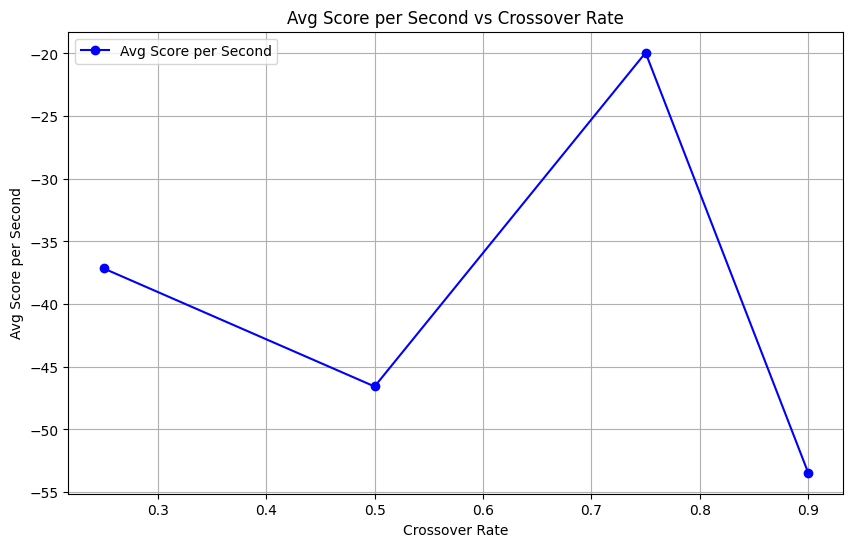

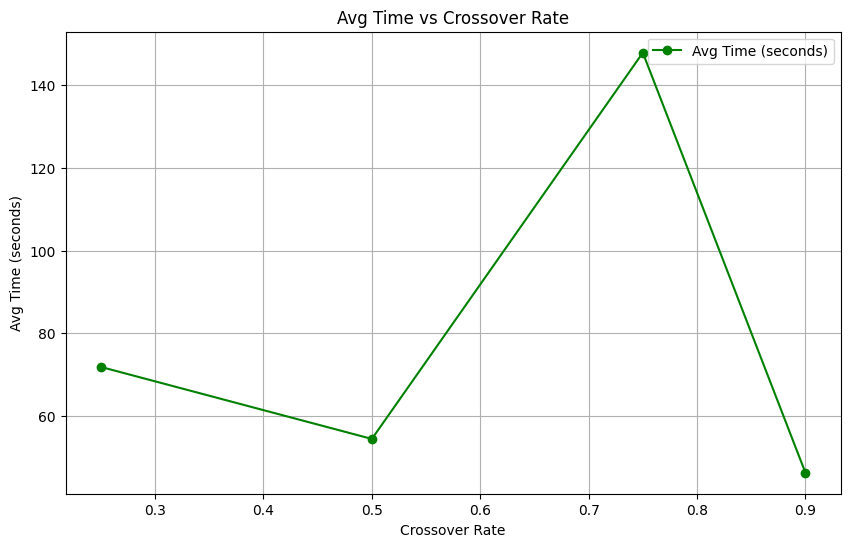

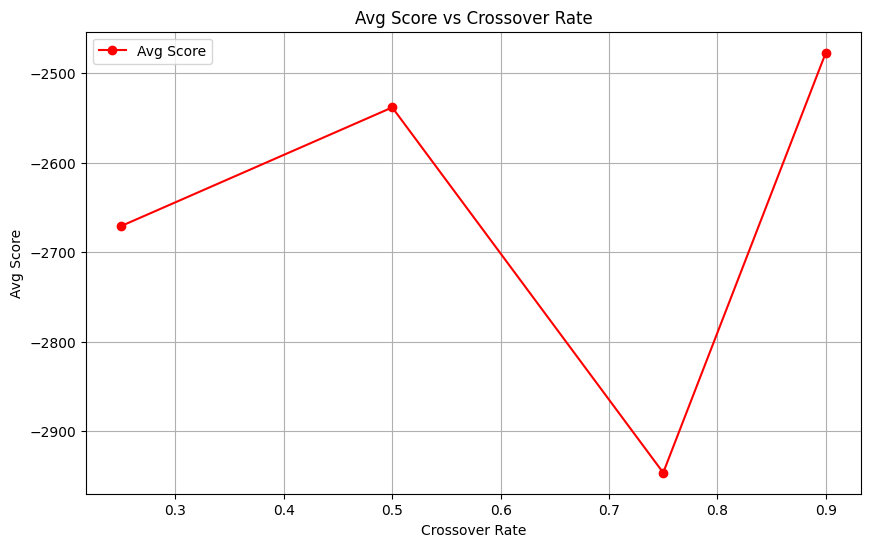

In [41]:
# Test different crossover rates
from genepro.variation import *
from datetime import datetime
import csv
import matplotlib.pyplot as plt

def test_crossover_rates(rates):
    data = []
    pop_size = 16
    max_gens = 10
    for rate in rates:
        total_time = 0
        total_score = 0
        for i in range(10):
            start = datetime.now()
            evo = Evolution(
                fitness_function_pt, internal_nodes, leaf_nodes,
                4,
                pop_size=pop_size,
                max_gens=max_gens,
                max_tree_size=31,
                n_jobs=8,
                verbose=True,
                crossovers=[{"fun": subtree_crossover, "rate": rate}]
            )
            evo.evolve()
            end = datetime.now()
            time = (end - start).total_seconds()
            best = evo.best_of_gens[-1]
            test_score = get_test_score(best)
            total_time += time
            total_score += test_score

        avg_time = total_time / 5
        avg_score = total_score / 5
        avg_score_per_second = avg_score / avg_time
        print(f"Crossover rate {rate}, avg_time {avg_time}, avg_score {avg_score}, avg_score_per_second {avg_score_per_second}")
        data.append([rate, avg_time, avg_score, avg_score_per_second])

    try:
        with open("crossover_rates.csv", mode='w', newline='') as file:
            writer = csv.writer(file)
            writer.writerow(["Crossover Rate", "Avg Time (seconds)", "Avg Test Score", "Avg Score per Second"])
            writer.writerows(data)
    except Exception as e:
        print("Error while writing file:", e)
    return data

def plot_crossover(data):
    rates = [entry[0] for entry in data]
    avg_times = [entry[1] for entry in data]
    avg_scores = [entry[2] for entry in data]
    avg_scores_per_second = [entry[3] for entry in data]

    # Plot Avg Score per Second vs Crossover Rate
    plt.figure(figsize=(10, 6))
    plt.plot(rates, avg_scores_per_second, marker='o', label='Avg Score per Second', color='blue')
    plt.title('Avg Score per Second vs Crossover Rate')
    plt.xlabel('Crossover Rate')
    plt.ylabel('Avg Score per Second')
    plt.grid(True)
    plt.legend()
    plt.savefig("avg_score_per_second_vs_crossover_rate.png")
    plt.show()

    # Plot Avg Time vs Crossover Rate
    plt.figure(figsize=(10, 6))
    plt.plot(rates, avg_times, marker='o', label='Avg Time (seconds)', color='green')
    plt.title('Avg Time vs Crossover Rate')
    plt.xlabel('Crossover Rate')
    plt.ylabel('Avg Time (seconds)')
    plt.grid(True)
    plt.legend()
    plt.savefig("avg_time_vs_crossover_rate.png")
    plt.show()

    # Plot Avg Score vs Crossover Rate
    plt.figure(figsize=(10, 6))
    plt.plot(rates, avg_scores, marker='o', label='Avg Score', color='red')
    plt.title('Avg Score vs Crossover Rate')
    plt.xlabel('Crossover Rate')
    plt.ylabel('Avg Score')
    plt.grid(True)
    plt.legend()
    plt.savefig("avg_score_vs_crossover_rate.png")
    plt.show()

def load_csv(filename):
    data = []
    with open(filename, mode='r', newline='') as file:
        reader = csv.reader(file)
        next(reader)
        for row in reader:
            data.append([float(row[0]), float(row[1]), float(row[2]), float(row[3])])
    return data

rates = [0.25, 0.5, 0.75, 0.9]
data = test_crossover_rates(rates)
# data = load_csv("crossover_rates.csv")
plot_crossover(data)


gen: 1,	best of gen fitness: -477.156,	best of gen size: 26
gen: 2,	best of gen fitness: -444.967,	best of gen size: 27
gen: 3,	best of gen fitness: -314.584,	best of gen size: 26
gen: 4,	best of gen fitness: -460.868,	best of gen size: 26
gen: 5,	best of gen fitness: -421.127,	best of gen size: 26
gen: 6,	best of gen fitness: -401.296,	best of gen size: 26
gen: 7,	best of gen fitness: -328.599,	best of gen size: 29
gen: 8,	best of gen fitness: -382.892,	best of gen size: 26
gen: 9,	best of gen fitness: -412.222,	best of gen size: 26
gen: 10,	best of gen fitness: -337.050,	best of gen size: 26
gen: 1,	best of gen fitness: -497.736,	best of gen size: 36
gen: 2,	best of gen fitness: -490.459,	best of gen size: 27
gen: 3,	best of gen fitness: -550.796,	best of gen size: 27
gen: 4,	best of gen fitness: -518.842,	best of gen size: 27
gen: 5,	best of gen fitness: -495.887,	best of gen size: 27
gen: 6,	best of gen fitness: -522.609,	best of gen size: 27
gen: 7,	best of gen fitness: -472.872,	

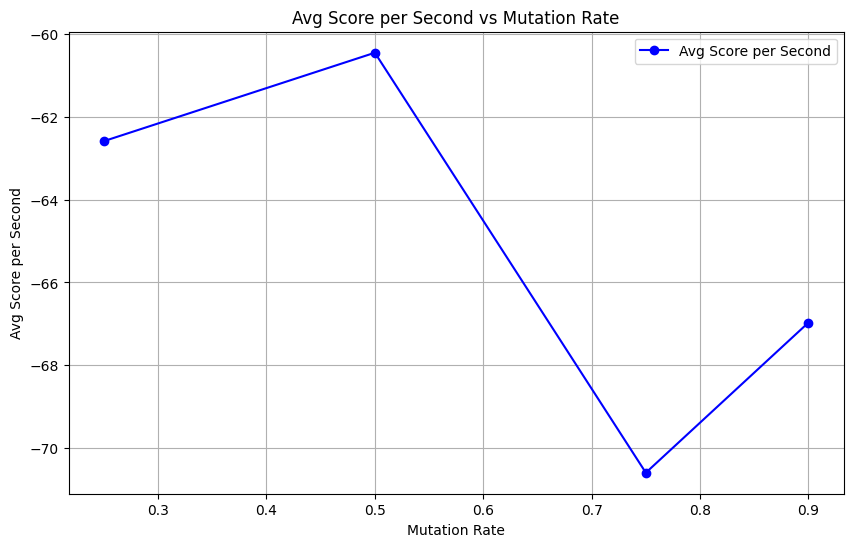

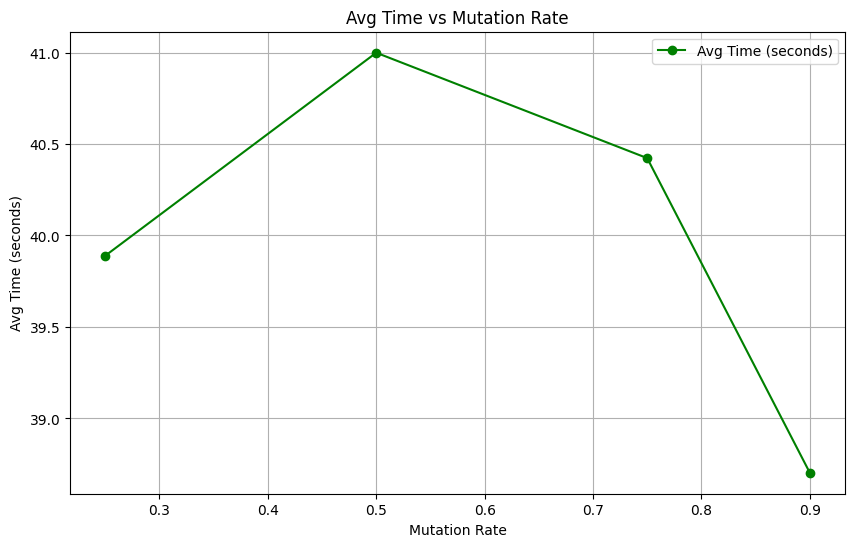

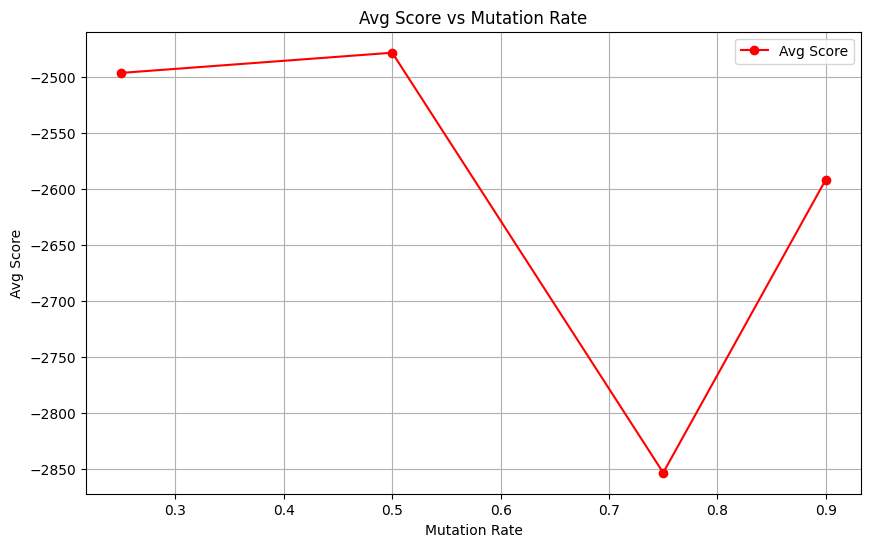

In [42]:
# Test different mutation rates
from genepro.variation import *
from datetime import datetime
import csv
import matplotlib.pyplot as plt

def test_mutation_rates(rates):
    data = []
    pop_size = 16
    max_gens = 10
    for rate in rates:
        total_time = 0
        total_score = 0
        for i in range(10):
            start = datetime.now()
            evo = Evolution(
                fitness_function_pt, internal_nodes, leaf_nodes,
                4,
                pop_size=pop_size,
                max_gens=max_gens,
                max_tree_size=31,
                n_jobs=8,
                verbose=True,
                mutations=[{"fun": subtree_mutation, "rate": rate}]
            )
            evo.evolve()
            end = datetime.now()
            time = (end - start).total_seconds()
            best = evo.best_of_gens[-1]
            test_score = get_test_score(best)
            total_time += time
            total_score += test_score

        avg_time = total_time / 5
        avg_score = total_score / 5
        avg_score_per_second = avg_score / avg_time
        print(f"Mutation rate {rate}, avg_time {avg_time}, avg_score {avg_score}, avg_score_per_second {avg_score_per_second}")
        data.append([rate, avg_time, avg_score, avg_score_per_second])

    try:
        with open("mutation_rates.csv", mode='w', newline='') as file:
            writer = csv.writer(file)
            writer.writerow(["Mutation Rate", "Avg Time (seconds)", "Avg Test Score", "Avg Score per Second"])
            writer.writerows(data)
    except Exception as e:
        print("Error while writing file:", e)
    return data

def plot_mutation(data):
    rates = [entry[0] for entry in data]
    avg_times = [entry[1] for entry in data]
    avg_scores = [entry[2] for entry in data]
    avg_scores_per_second = [entry[3] for entry in data]

    # Plot Avg Score per Second vs Mutation Rate
    plt.figure(figsize=(10, 6))
    plt.plot(rates, avg_scores_per_second, marker='o', label='Avg Score per Second', color='blue')
    plt.title('Avg Score per Second vs Mutation Rate')
    plt.xlabel('Mutation Rate')
    plt.ylabel('Avg Score per Second')
    plt.grid(True)
    plt.legend()
    plt.savefig("avg_score_per_second_vs_mutation_rate.png")
    plt.show()

    # Plot Avg Time vs Mutation Rate
    plt.figure(figsize=(10, 6))
    plt.plot(rates, avg_times, marker='o', label='Avg Time (seconds)', color='green')
    plt.title('Avg Time vs Mutation Rate')
    plt.xlabel('Mutation Rate')
    plt.ylabel('Avg Time (seconds)')
    plt.grid(True)
    plt.legend()
    plt.savefig("avg_time_vs_mutation_rate.png")
    plt.show()

    # Plot Avg Score vs Mutation Rate
    plt.figure(figsize=(10, 6))
    plt.plot(rates, avg_scores, marker='o', label='Avg Score', color='red')
    plt.title('Avg Score vs Mutation Rate')
    plt.xlabel('Mutation Rate')
    plt.ylabel('Avg Score')
    plt.grid(True)
    plt.legend()
    plt.savefig("avg_score_vs_mutation_rate.png")
    plt.show()

rates = [0.25, 0.5, 0.75, 0.9]
data = test_mutation_rates(rates)
# data = load_csv("mutation_rates.csv")
plot_mutation(data)


In [ ]:
# Experiment setup

from genepro.variation import *

def experiment():
    max_gens = 50
    all_test_scores = [[] for _ in range(max_gens+1)]
    best_successful_landing_time = None
    for i in range(10):
        start = datetime.now()
        evo = Evolution(
            fitness_function_pt, internal_nodes, leaf_nodes,
            4,
            pop_size=48,
            max_gens=max_gens,
            max_tree_size=31,
            n_jobs=8,
            verbose=True,
            crossovers=[{"fun": subtree_crossover, "rate": 0.75}],
            mutations=[{"fun": subtree_mutation, "rate": 0.5}])
        evo.evolve()
        end = datetime.now()
        time = (end - start).total_seconds()
        best_of_gens = evo.best_of_gens
        for gen_index, best in enumerate(best_of_gens):
            test_score = get_test_score(best)
            # test_score = best.fitness
            all_test_scores[gen_index].append(test_score)

            if test_score >= 200:
                proportional_time = time * (gen_index / max_gens)
                if best_successful_landing_time is None or proportional_time < best_successful_landing_time:
                    best_successful_landing_time = proportional_time
    avg_test_scores = []
    for scores in all_test_scores[:max_gens]:
        avg_test_scores.append(np.mean(scores))
    
    with open("avg_test_scores_baseline.csv", mode="w", newline="") as file:
        writer = csv.writer(file)
        writer.writerow(["Generation", "Average Test Score"])
        for generation, avg_score in enumerate(avg_test_scores, start=1):
            writer.writerow([generation, avg_score])


    return avg_test_scores, best_successful_landing_time

def plot_scores_over_generations(avg_test_scores):
    generations = list(range(1, len(avg_test_scores) + 1))
    plt.figure(figsize=(10, 6))
    plt.plot(generations, avg_test_scores, marker='o', label='Avg Test Score')
    plt.title('Average Test Score per Generation')
    plt.xlabel('Generation')
    plt.ylabel('Average Test Score')
    plt.grid(True)
    plt.legend()
    plt.show()

# Example Usage
avg_test_scores, best_successful_landing_time = experiment()
plot_scores_over_generations(avg_test_scores)
print(f"best successful landing time: {best_successful_landing_time}")

gen: 1,	best of gen fitness: -460.899,	best of gen size: 44
gen: 2,	best of gen fitness: -372.002,	best of gen size: 30
gen: 3,	best of gen fitness: -453.855,	best of gen size: 30
gen: 4,	best of gen fitness: -287.825,	best of gen size: 27
gen: 5,	best of gen fitness: -361.801,	best of gen size: 30
gen: 6,	best of gen fitness: -252.401,	best of gen size: 30
gen: 7,	best of gen fitness: -264.621,	best of gen size: 30
gen: 8,	best of gen fitness: -211.093,	best of gen size: 31
gen: 9,	best of gen fitness: -141.365,	best of gen size: 31
gen: 10,	best of gen fitness: -220.820,	best of gen size: 31
gen: 11,	best of gen fitness: -231.230,	best of gen size: 31
gen: 12,	best of gen fitness: 262.829,	best of gen size: 28
gen: 13,	best of gen fitness: 67.638,	best of gen size: 28
gen: 14,	best of gen fitness: 407.939,	best of gen size: 28
gen: 15,	best of gen fitness: 648.574,	best of gen size: 28
gen: 16,	best of gen fitness: 66.510,	best of gen size: 31
gen: 17,	best of gen fitness: 343.635,	b

## Make an animation
Here the best evolved individual is selected and one episode is rendered. Make sure to save your lunar landers over time to track progress and make comparisons.

MovieWriter imagemagick unavailable; using Pillow instead.


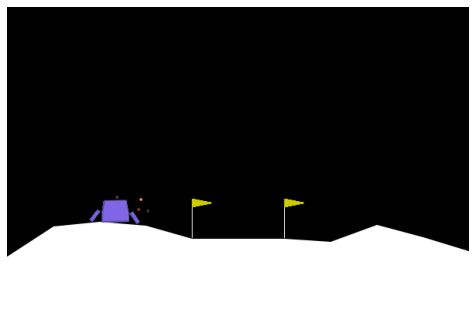

In [ ]:
frames = []

# gist to save gif from https://gist.github.com/botforge/64cbb71780e6208172bbf03cd9293553
def save_frames_as_gif(frames, path='./', filename='evolved_lander.gif'):
  plt.figure(figsize=(frames[0].shape[1] / 72.0, frames[0].shape[0] / 72.0), dpi=72)
  patch = plt.imshow(frames[0])
  plt.axis('off')
  def animate(i):
      patch.set_data(frames[i])
  anim = animation.FuncAnimation(plt.gcf(), animate, frames = len(frames), interval=50)
  anim.save(path + filename, writer='imagemagick', fps=60)

frames = []
fitness_function_pt(best, num_episodes=1, episode_duration=500, render=True, ignore_done=False)
env.close()
print(frames)
save_frames_as_gif(frames)

## Play animation

<img src="evolved_lander.gif" width="750">

## Optimisation
The coefficients in the multi-tree aren't optimised. Here Q-learning (taken from https://pytorch.org/tutorials/intermediate/reinforcement_q_learning.html) is used to optimise the weights further. Incorporate coefficient optimisation in training your agent(s). Coefficient Optimisation can be expensive. Think about how often you want to optimise, when, which individuals etc.

In [ ]:
batch_size = 128
GAMMA = 0.99

constants = best.get_subtrees_consts()

if len(constants)>0:
  optimizer = optim.AdamW(constants, lr=1e-3, amsgrad=True)

for _ in range(500):

  if len(constants)>0 and len(evo.memory)>batch_size:
    target_tree = copy.deepcopy(best)

    transitions = evo.memory.sample(batch_size)
    batch = Transition(*zip(*transitions))
    
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                        batch.next_state)), dtype=torch.bool)

    non_final_next_states = torch.cat([s for s in batch.next_state
                                               if s is not None])
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    state_action_values = best.get_output_pt(state_batch).gather(1, action_batch)
    next_state_values = torch.zeros(batch_size, dtype=torch.float)
    with torch.no_grad():
      out = target_tree.get_output_pt(non_final_next_states).max(1)[0].float()
      print("out", out)
      next_state_values[non_final_mask] = out
      

    expected_state_action_values = (next_state_values * GAMMA) + reward_batch
    
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))
   
    # Optimize the model
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_value_(constants, 100)
    optimizer.step()

print(best.get_readable_repr())
print(get_test_score(best))

['((((x_2-x_2)+(x_3*x_1))*(x_6/x_6))+(((x_3-x_1)/x_4)+(x_0+x_5)))', '((x_7-x_5)/(((x_1/x_6)/x_6)*x_7))', '((((x_0-x_2)*x_7)+(x_2+x_5))+((x_0/(x_5/x_6))-((x_6-x_4)+(x_1+x_1))))', '(x_3-x_6)']
-650.0875451188124


MovieWriter imagemagick unavailable; using Pillow instead.


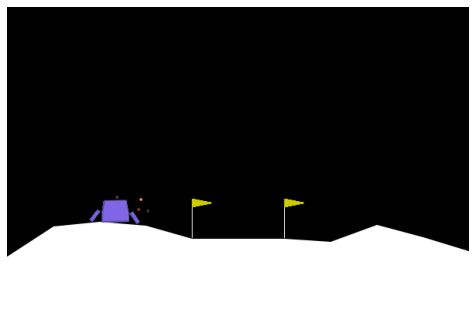

In [ ]:
frames = []
fitness_function_pt(best, num_episodes=1, episode_duration=500, render=True, ignore_done=False)
env.close()
save_frames_as_gif(frames, filename='evolved_lander_RL.gif')

<img src="evolved_lander_RL.gif" width="750">